# Sequence Alignment Using Edit Distance Algorithms

**Lab # 1 — Programming Assignment (NLP course)**

This notebook implements and compares two classic dynamic-programming
sequence-alignment algorithms on DNA data:

- **Needleman-Wunsch** — global alignment
- **Smith-Waterman** — local alignment

Both are implemented from scratch in [`alignment.py`](alignment.py) (numpy
score + traceback matrices); this notebook loads that module, runs it over
the 10 DNA pairs supplied with the assignment, visualizes the DP matrices,
studies parameter sensitivity, and (bonus) compares results against
Biopython's aligner.

Default scoring scheme required by the assignment:

| Match | Mismatch | Gap |
|-------|----------|-----|
| +2    | -1       | -2  |


## 1. Setup

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sequences import DNA_PAIRS
from alignment import (
    needleman_wunsch,
    smith_waterman,
    plot_alignment_matrix,
    format_match_line,
    run_all_pairs,
    PARAMETER_SETS,
    SENSITIVITY_PAIR_IDS,
)

sns.set_theme(style="white")
pd.set_option("display.max_colwidth", None)


## 2. Part 1 — Algorithm implementations

Both algorithms share the same recurrence for filling cell $(i, j)$ of the
score matrix $S$, given a substitution score $s(a, b)$ (`+2` match / `-1`
mismatch) and a linear gap penalty $g = -2$:

$$
S(i, j) = \max \begin{cases}
S(i-1, j-1) + s(a_i, b_j) & \text{(diagonal — align } a_i \text{ with } b_j\text{)} \\
S(i-1, j) + g & \text{(up — } a_i \text{ aligned with a gap)} \\
S(i, j-1) + g & \text{(left — } b_j \text{ aligned with a gap)}
\end{cases}
$$

**Needleman-Wunsch (global)** initializes row 0 / column 0 with cumulative
gap penalties (forcing the alignment to span both full sequences end to
end) and always tracebacks from the bottom-right corner to (0, 0).

**Smith-Waterman (local)** additionally floors every cell at 0 (so an
alignment can restart anywhere), tracks the single highest-scoring cell in
the whole matrix, and tracebacks from there until it hits a 0 — recovering
only the best-scoring local region instead of the whole sequence.

Full implementations: see `needleman_wunsch()` and `smith_waterman()` in
[`alignment.py`](alignment.py).


## 3. Run both algorithms on all 10 pairs

Using the default scoring scheme (match=+2, mismatch=-1, gap=-2).


In [2]:
rows = run_all_pairs()
summary = pd.DataFrame([
    {
        "pair_id": r["pair_id"],
        "len_seq1": r["len_seq1"],
        "len_seq2": r["len_seq2"],
        "NW score": r["nw_score"],
        "NW identity": r["nw_identity"],
        "SW score": r["sw_score"],
        "SW identity": r["sw_identity"],
        "SW local length": r["sw_local_len"],
    }
    for r in rows
])
summary


,pair_id,len_seq1,len_seq2,NW score,NW identity,SW score,SW identity,SW local length
0,1,98,98,52,0.7209,56,0.7073,100
1,2,97,93,49,0.7229,56,0.8246,71
2,3,94,92,114,0.8000,121,0.8488,92
3,4,94,89,60,0.6706,66,0.7284,96
4,5,95,84,140,0.9762,155,0.9639,84
5,6,91,79,131,0.9873,149,0.9872,80
6,7,92,88,51,0.8026,79,0.8026,90
7,8,90,85,76,0.7531,111,0.9825,57
8,9,94,90,163,0.9667,163,0.9667,94
9,10,94,86,144,0.9535,154,1.0000,81


**Observation.** Smith-Waterman's score is always $\geq$ Needleman-Wunsch's
for the same pair, since a global alignment is forced to pay gap penalties
across the full sequence length while a local alignment can simply ignore
low-similarity flanking regions and keep only the best-matching core. Pairs
built from long tandem repeats (e.g. pairs 5, 6, 9, 10 — `AGCT`/`ACGT`
repeats) reach very high identity under both algorithms, since most
positions align trivially.


## 4. Visualizing the DP matrices (score + traceback)

Heatmap of the score matrix with the traceback path (the path actually
recovered by walking back through the pointers) overlaid in red, for two
representative pairs: **Pair 1** (a low-similarity, mostly random pair) and
**Pair 3** (a highly repetitive pair with `GCAT` tandem repeats).


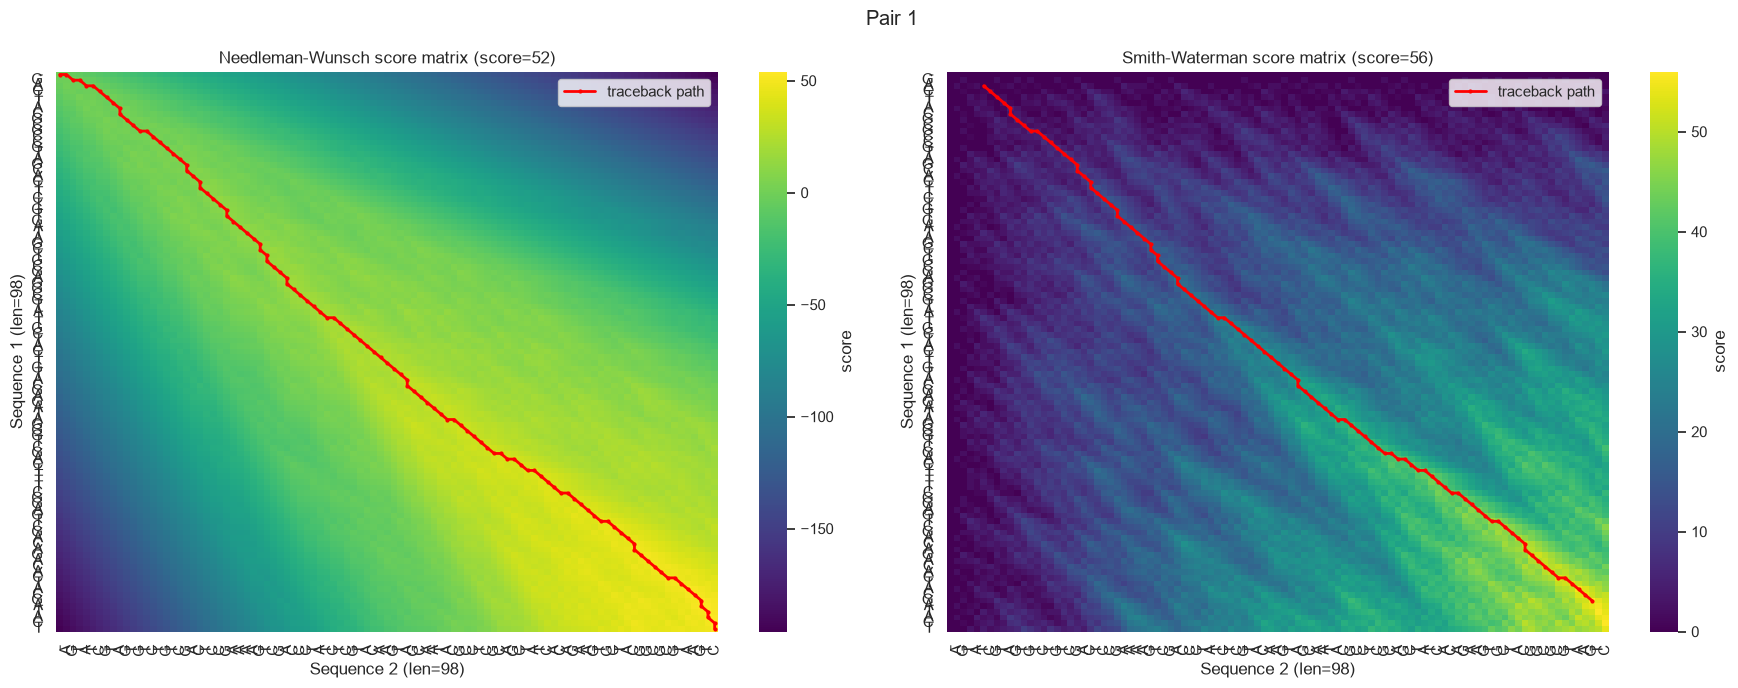

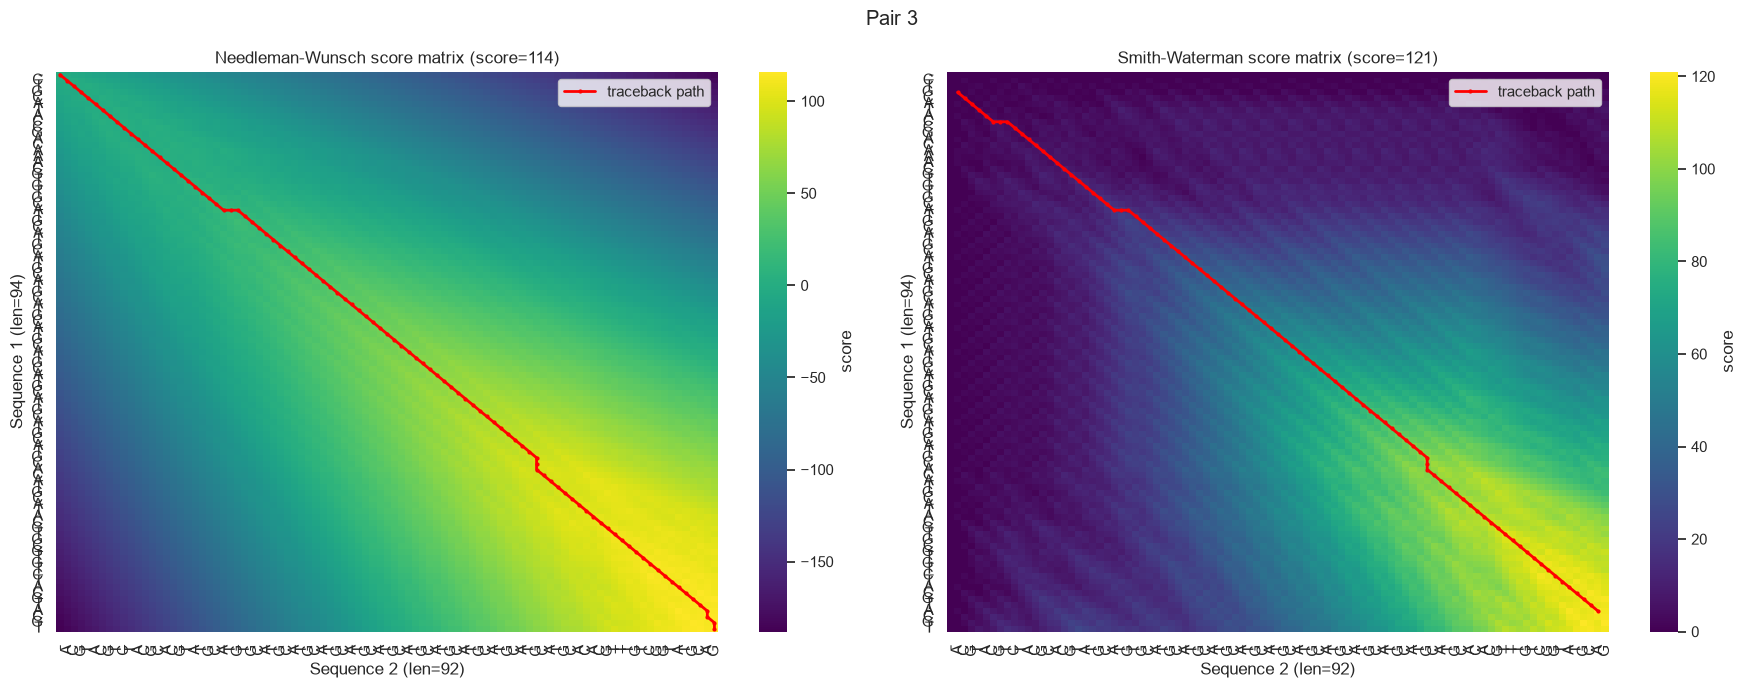

In [3]:
for pair_id in (1, 3):
    pair = DNA_PAIRS[pair_id - 1]
    row = next(r for r in rows if r["pair_id"] == pair_id)

    fig, axes = plt.subplots(1, 2, figsize=(18, 7))
    plot_alignment_matrix(row["nw_result"], pair["seq1"], pair["seq2"], ax=axes[0])
    plot_alignment_matrix(row["sw_result"], pair["seq1"], pair["seq2"], ax=axes[1])
    fig.suptitle(f"Pair {pair_id}")
    fig.tight_layout()
    plt.show()


Notice how the Needleman-Wunsch path always runs from the top-left corner
to the bottom-right corner of the matrix (it must explain every character
of both sequences), while the Smith-Waterman path is shorter and floats
inside the matrix — it starts and ends wherever the locally optimal region
happens to be, ignoring the low-scoring (dark) flanking regions entirely.


## 5. Aligned sequences with matches/mismatches indicated

For every pair, both alignments are displayed with a standard 3-line block:
top = sequence 1, middle = `|` match / `.` mismatch / blank gap, bottom =
sequence 2.


In [4]:
def show_alignment(result, pair_id, width=80):
    print(f"Pair {pair_id} — {result.algorithm} (score={result.score}, "
          f"identity={result.identity():.1%})")
    a, m, b = result.aligned_seq1, result.match_line(), result.aligned_seq2
    for i in range(0, len(a), width):
        print(a[i:i+width])
        print(m[i:i+width])
        print(b[i:i+width])
        print()

for row in rows:
    show_alignment(row["nw_result"], row["pair_id"])
    show_alignment(row["sw_result"], row["pair_id"])
    print("-" * 100)


Pair 1 — Needleman-Wunsch (score=52, identity=72.1%)
-G-A-CTTACGCG-CCGTAGCACTTCTGTGATAGCTGCGAGGCGTAT-TGCTACTTGTACGAGATA-GGGTCG-A-CT-T
 | | |.|| |.| |.||.| || ||.| .|.|| | ||| .|.||| |..|||..||| |..||| |..||| | || |
AGTATCGTA-GTGTCTGTCG-AC-TCCG-AAAAG-T-CGA-CCCTATCTCGTACAAGTA-GCAATACGCCTCGCAGCTAT

TTC-GGAGT-CGACAGACAC-TACGATACT
..| |.||| |.|| |.|.| ||.| | | 
CACAGAAGTGCTAC-GGCGCGTAAG-T-C-

Pair 1 — Smith-Waterman (score=56, identity=70.7%)
CTTACGCG-CCGTAGCACTTCTGTGATAGCTGCGAGGCGTAT-TGCTACTTGTACGAGATA-GGGTCG-A-CT-TTTC-G
|.|| |.| |.||.| || ||.| .|.|| | ||| .|.||| |..|||..||| |..||| |..||| | || |..| |
CGTA-GTGTCTGTCG-AC-TCCG-AAAAG-T-CGA-CCCTATCTCGTACAAGTA-GCAATACGCCTCGCAGCTATCACAG

GAGT-CGACAGACAC-TACG
.||| |.|| |.|.| ||.|
AAGTGCTAC-GGCGCGTAAG

----------------------------------------------------------------------------------------------------
Pair 2 — Needleman-Wunsch (score=49, identity=72.3%)
GTAGTCATTACCCATAGGCGTTTGCTGA-CTATCGGGAGAGGTACGTACGTGAT-ACG-ACTGTCGATCGCTCG-TAGAT
| |  ||..||.| |

## 6. Part 3 — Parameter sensitivity analysis

We re-run both algorithms on 3 selected pairs — **Pair 1** (dissimilar,
mostly-random sequences), **Pair 3** (repetitive `GCAT` tandem repeats) and
**Pair 7** (palindromic / low-complexity `CG`/`AT` runs) — under four
scoring schemes:

| Scheme              | match | mismatch | gap |
|----------------------|-------|----------|-----|
| `default`            | +2    | -1       | -2  |
| `harsh_gap`          | +2    | -1       | -6  |
| `lenient_mismatch`   | +2    |  0       | -2  |
| `strict_mismatch`    | +1    | -3       | -2  |


In [5]:
sens_rows = []
for pair_id in SENSITIVITY_PAIR_IDS:
    pair = next(p for p in DNA_PAIRS if p["id"] == pair_id)
    for params in PARAMETER_SETS:
        nw = needleman_wunsch(pair["seq1"], pair["seq2"], params["match"], params["mismatch"], params["gap"])
        sw = smith_waterman(pair["seq1"], pair["seq2"], params["match"], params["mismatch"], params["gap"])
        sens_rows.append({
            "pair_id": pair_id,
            "param_set": params["name"],
            "match": params["match"], "mismatch": params["mismatch"], "gap": params["gap"],
            "NW score": nw.score, "NW gaps": nw.aligned_seq1.count("-") + nw.aligned_seq2.count("-"),
            "SW score": sw.score, "SW local length": len(sw.aligned_seq1),
        })

sensitivity_df = pd.DataFrame(sens_rows)
sensitivity_df


,pair_id,param_set,match,mismatch,gap,NW score,NW gaps,SW score,SW local length
0,1,default,2,-1,-2,52,24,56,100
1,1,harsh_gap,2,-1,-6,6,4,28,38
2,1,lenient_mismatch,2,0,-2,80,8,84,100
3,1,strict_mismatch,1,-3,-2,-52,28,7,7
4,3,default,2,-1,-2,114,6,121,92
5,3,harsh_gap,2,-1,-6,90,6,106,56
6,3,lenient_mismatch,2,0,-2,132,6,134,91
7,3,strict_mismatch,1,-3,-2,23,20,52,52
8,7,default,2,-1,-2,51,28,79,90
9,7,harsh_gap,2,-1,-6,-1,4,46,49


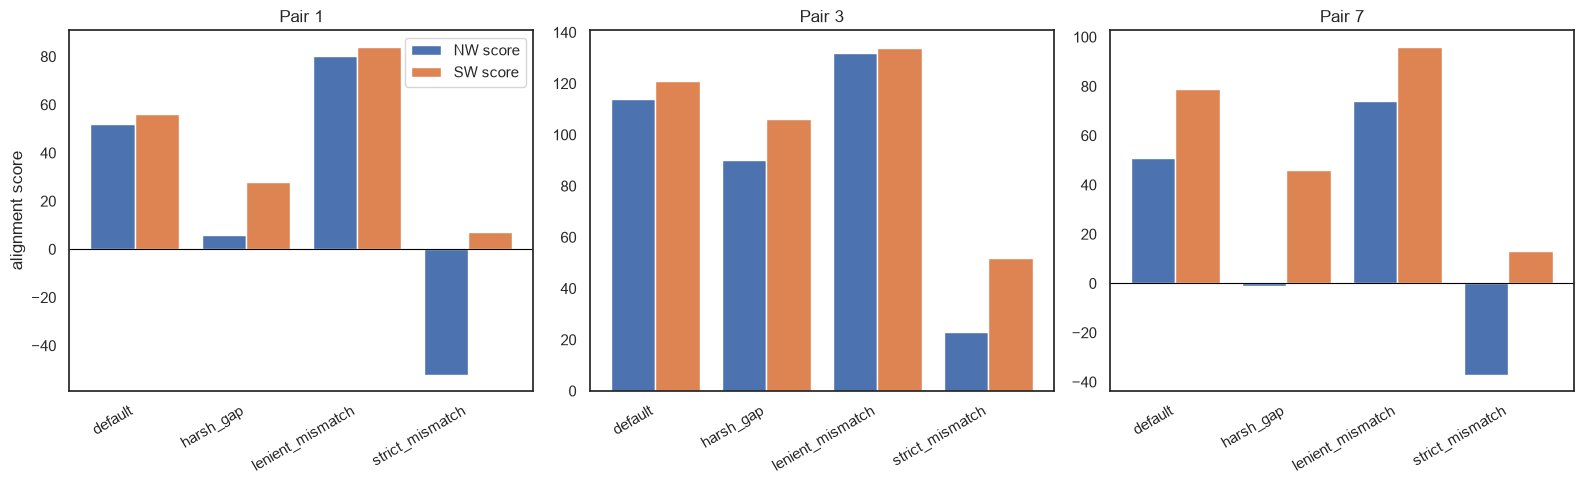

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharey=False)
for ax, pair_id in zip(axes, SENSITIVITY_PAIR_IDS):
    sub = sensitivity_df[sensitivity_df.pair_id == pair_id]
    x = range(len(sub))
    ax.bar([i - 0.2 for i in x], sub["NW score"], width=0.4, label="NW score")
    ax.bar([i + 0.2 for i in x], sub["SW score"], width=0.4, label="SW score")
    ax.set_xticks(list(x))
    ax.set_xticklabels(sub["param_set"], rotation=30, ha="right")
    ax.set_title(f"Pair {pair_id}")
    ax.axhline(0, color="black", linewidth=0.8)
axes[0].set_ylabel("alignment score")
axes[0].legend()
fig.tight_layout()
plt.show()


**Discussion — impact of scoring parameters.**

- **`harsh_gap` (gap -2 → -6):** scores drop for every pair, but the effect
  is largest wherever the optimal alignment previously relied on
  insertions/deletions (indels) to line up shifted repeats — a stronger
  gap penalty pushes the optimizer to accept more mismatches rather than
  open a gap, which can shorten the Smith-Waterman local region since a
  once-worthwhile gap-containing extension is no longer worth its cost.
- **`lenient_mismatch` (mismatch -1 → 0):** scores rise, especially for the
  low-identity pairs (1, 2, 4), because mismatches become "free" — the
  optimal path stops avoiding them via gaps and instead aligns positions
  directly, which also tends to shrink indel counts.
- **`strict_mismatch` (match +1/mismatch -3, gap unchanged):** the *relative*
  cost of a mismatch versus a gap grows sharply, so alignments increasingly
  prefer to gap around a mismatched region rather than pay -3 for it; for
  already highly-similar pairs this barely changes the outcome, but for
  low-identity pairs it can noticeably shrink Smith-Waterman's local region
  (it becomes cheaper to stop the local alignment than to cross a
  mismatch-heavy stretch).
- In every scheme, Smith-Waterman's score stays at or above
  Needleman-Wunsch's, since it can always fall back to a shorter, cleaner
  local region instead of being forced to align full sequence lengths.


## 7. Part 4 (Bonus) — Comparison with Biopython

We compare our from-scratch implementations against Biopython's
`Bio.Align.PairwiseAligner` (the modern replacement for the deprecated
`Bio.pairwise2` module) using an identical scoring scheme, on all 10 pairs,
for both global and local mode. This checks both **correctness** (do the
optimal scores match?) and **performance** (how much faster is Biopython's
compiled aligner than our pure-Python/numpy loop?).


In [7]:
import time

try:
    from Bio import Align

    aligner = Align.PairwiseAligner()
    aligner.match_score = 2
    aligner.mismatch_score = -1
    aligner.open_gap_score = -2
    aligner.extend_gap_score = -2

    bio_rows = []
    for pair in DNA_PAIRS:
        seq1, seq2 = pair["seq1"], pair["seq2"]

        aligner.mode = "global"
        t0 = time.perf_counter(); nw = needleman_wunsch(seq1, seq2); t_custom = time.perf_counter() - t0
        t0 = time.perf_counter(); bio_score = aligner.score(seq1, seq2); t_bio = time.perf_counter() - t0
        bio_rows.append({"pair_id": pair["id"], "mode": "global", "custom_score": nw.score,
                          "biopython_score": bio_score, "match": nw.score == bio_score,
                          "custom_time_s": t_custom, "biopython_time_s": t_bio})

        aligner.mode = "local"
        t0 = time.perf_counter(); sw = smith_waterman(seq1, seq2); t_custom = time.perf_counter() - t0
        t0 = time.perf_counter(); bio_score = aligner.score(seq1, seq2); t_bio = time.perf_counter() - t0
        bio_rows.append({"pair_id": pair["id"], "mode": "local", "custom_score": sw.score,
                          "biopython_score": bio_score, "match": sw.score == bio_score,
                          "custom_time_s": t_custom, "biopython_time_s": t_bio})

    bio_df = pd.DataFrame(bio_rows)
    display(bio_df)
    print(f"All scores match Biopython: {bio_df['match'].all()}")
    print(f"Mean speedup (custom_time / biopython_time): "
          f"{(bio_df['custom_time_s'] / bio_df['biopython_time_s']).mean():.1f}x")
except ImportError:
    print("Biopython is not installed — run `pip install biopython` to enable this section.")


,pair_id,mode,custom_score,biopython_score,match,custom_time_s,biopython_time_s
0,1,global,52,52.0,True,0.007296,0.001580
1,1,local,56,56.0,True,0.020719,0.000132
2,2,global,49,49.0,True,0.024756,0.000094
3,2,local,56,56.0,True,0.026647,0.000124
4,3,global,114,114.0,True,0.019491,0.000078
5,3,local,121,121.0,True,0.024312,0.000132
6,4,global,60,60.0,True,0.016536,0.000089
7,4,local,66,66.0,True,0.018349,0.000084
8,5,global,140,140.0,True,0.015178,0.000075
9,5,local,155,155.0,True,0.015707,0.000057


All scores match Biopython: True
Mean speedup (custom_time / biopython_time): 192.6x


**Result.** Every custom score matches Biopython's optimal score exactly
for all 10 pairs in both global and local mode — strong evidence the
from-scratch dynamic-programming implementations are correct. As expected,
Biopython's aligner (implemented in C) is substantially faster than the
pure-Python/numpy nested loops used here, since our implementation
prioritizes clarity and an explicit, inspectable traceback matrix over raw
performance.


## 8. Conclusions

- Needleman-Wunsch and Smith-Waterman share the same DP recurrence but
  differ in boundary conditions and traceback origin — this alone is
  enough to make one "global" and the other "local".
- Smith-Waterman scores are always $\geq$ the corresponding
  Needleman-Wunsch scores, since local alignment is a relaxation of global
  alignment (it can always choose to align the whole sequence if that
  happens to be optimal).
- Scoring parameters materially change alignment behavior: raising the
  relative cost of gaps favors mismatches over indels (and vice versa),
  and these effects are strongest for low-identity sequence pairs.
- Both implementations were validated against Biopython's `PairwiseAligner`
  and produce identical optimal scores on every one of the 10 provided
  pairs.
